In [67]:
import matplotlib.pyplot as plt
import numpy as np

In [68]:
dach_length = [77, 78, 85, 83, 73, 77, 73, 80]
dach_height = [25, 28, 29, 30, 21, 22, 17, 35]

In [69]:
samo_length = [75, 77, 86, 86, 79, 83, 83, 88]
samo_height = [56, 57, 50, 53, 60, 53, 49, 61]

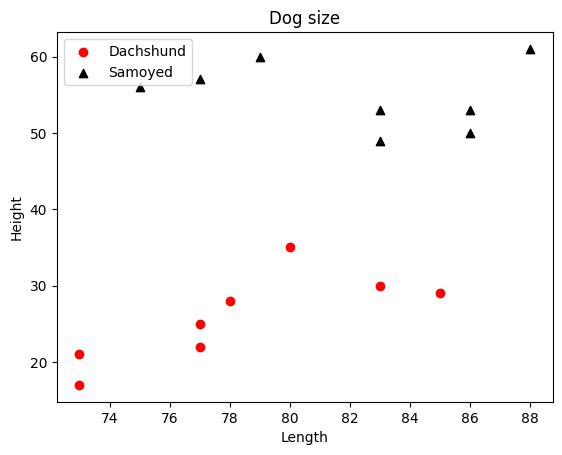

In [70]:
plt.scatter(dach_length, dach_height, c='red', label='Dachshund')
plt.scatter(samo_length, samo_height,c='black',marker='^', label='Samoyed')
plt.xlabel('Length')
plt.ylabel('Height')
plt.title("Dog size")
plt.legend(loc='upper left')
plt.show()

In [71]:
dach_data = np.column_stack((dach_length, dach_height))
print(dach_data)
print(dach_data.shape)

[[77 25]
 [78 28]
 [85 29]
 [83 30]
 [73 21]
 [77 22]
 [73 17]
 [80 35]]
(8, 2)


In [72]:
dach_target = np.zeros

In [73]:
print(dach_target)

<built-in function zeros>


In [74]:
samo_data = np.column_stack((samo_length, samo_height))

In [75]:
samo_target = np.zeros

In [103]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 랜덤 데이터를 같게 보기 위해 seed를 고정한다.
np.random.seed(42)

# 새 닥스훈트 200마리
new_dach_length = np.random.normal(72, 5, 200)
new_dach_height = np.random.normal(24, 5, 200)

# 새 사모예드 200마리
new_samo_length = np.random.normal(92, 5, 200)
new_samo_height = np.random.normal(58, 5, 200)

new_dach_data = np.column_stack((new_dach_length, new_dach_height))
new_samo_data = np.column_stack((new_samo_length, new_samo_height))

new_dach_target = np.zeros(len(new_dach_data))
new_samo_target = np.ones(len(new_samo_data))

new_X = np.concatenate((new_dach_data, new_samo_data))
new_y = np.concatenate((new_dach_target, new_samo_target))

print('new_X shape:', new_X.shape)
print('new_y shape:', new_y.shape)
print('new_dach_data:', len(new_dach_data), '마리')
print('new_samo_data:', len(new_samo_data), '마리')

new_X shape: (400, 2)
new_y shape: (400,)
new_dach_data: 200 마리
new_samo_data: 200 마리


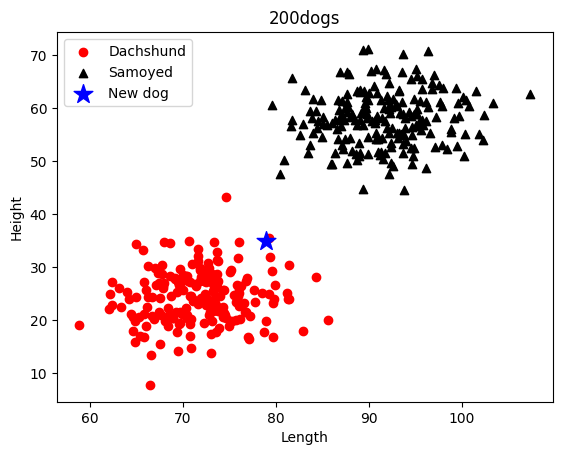

In [110]:
new_dog = np.array([[79, 35]])

plt.scatter(new_dach_length, new_dach_height, c='red', label='Dachshund')
plt.scatter(new_samo_length, new_samo_height, c='black', marker='^', label='Samoyed')
plt.scatter(new_dog[:, 0], new_dog[:, 1], c='blue', marker='*', s=200, label='New dog')

plt.xlabel('Length')
plt.ylabel('Height')
plt.title('200dogs')
plt.legend(loc='upper left')
plt.show()

In [105]:
new_dog_classes = {
    0: 'Dachshund',
    1: 'Samoyed'
}

new_knn = KNeighborsClassifier(n_neighbors=3)
new_knn.fit(new_X, new_y)

new_pred = new_knn.predict(new_dog)

print('예측 번호:', int(new_pred[0]))
print('예측 품종:', new_dog_classes[int(new_pred[0])])

예측 번호: 0
예측 품종: Dachshund


In [106]:
new_X_train, new_X_test, new_y_train, new_y_test = train_test_split(
    new_X,
    new_y,
    test_size=0.25,
    random_state=42,
    stratify=new_y
)

new_knn_test = KNeighborsClassifier(n_neighbors=3)
new_knn_test.fit(new_X_train, new_y_train)

new_test_pred = new_knn_test.predict(new_X_test)
new_score = accuracy_score(new_y_test, new_test_pred)

print('검증 데이터 정답:', new_y_test.astype(int))
print('검증 데이터 예측:', new_test_pred.astype(int))
print('정확도:', new_score)

검증 데이터 정답: [1 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0 0 1 1 1 1 0 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0
 1 0 1 1 0 0 1 1 0 1 0 0 1 1 0 1 0 1 1 0 0 1 1 1 1 1 1 0 0 0 1 1 0 0 1 1 1
 0 1 1 0 1 0 1 0 0 1 1 0 1 0 0 0 1 0 0 1 1 1 1 0 1 0]
검증 데이터 예측: [1 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0 0 1 1 1 1 0 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0
 1 0 1 1 0 0 1 1 0 1 0 0 1 1 0 1 0 1 1 0 0 1 1 1 1 1 1 0 0 0 1 1 0 0 1 1 1
 0 1 1 0 1 0 1 0 0 1 1 0 1 0 0 0 1 0 0 1 1 1 1 0 1 0]
정확도: 1.0


In [107]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 회귀의 입력 X: [몸 길이, 품종 코드]
# 품종 코드: 0 = Dachshund, 40 = Samoyed
# 길이 값과 비슷한 크기로 맞추기 위해 사모예드 코드를 40으로 사용한다.
new_reg_length = np.concatenate((new_dach_length, new_samo_length))
new_reg_breed = np.concatenate((np.zeros(len(new_dach_length)), np.ones(len(new_samo_length)) * 40))
new_reg_X = np.column_stack((new_reg_length, new_reg_breed))

# 회귀의 정답 y: 몸 높이
new_reg_y = np.concatenate((new_dach_height, new_samo_height))

new_reg_X_train, new_reg_X_test, new_reg_y_train, new_reg_y_test = train_test_split(
    new_reg_X,
    new_reg_y,
    test_size=0.25,
    random_state=42
)

new_knn_reg = KNeighborsRegressor(n_neighbors=3)
new_knn_reg.fit(new_reg_X_train, new_reg_y_train)

new_reg_pred = new_knn_reg.predict(new_reg_X_test)
new_mae = mean_absolute_error(new_reg_y_test, new_reg_pred)
new_r2 = r2_score(new_reg_y_test, new_reg_pred)

print('MAE:', new_mae)
print('R2 score:', new_r2)

MAE: 4.7655288529873925
R2 score: 0.8684146977740332


In [108]:
# 몸 길이가 79인 닥스훈트와 사모예드의 몸 높이를 회귀로 예측해 본다.
new_reg_dogs = np.array([
    [79, 0],  # Dachshund
    [79, 40],  # Samoyed
])

new_reg_dog_pred = new_knn_reg.predict(new_reg_dogs)

print('Dachshund height prediction:', new_reg_dog_pred[0])
print('Samoyed height prediction:', new_reg_dog_pred[1])

Dachshund height prediction: 20.862230234233383
Samoyed height prediction: 55.81307158202511


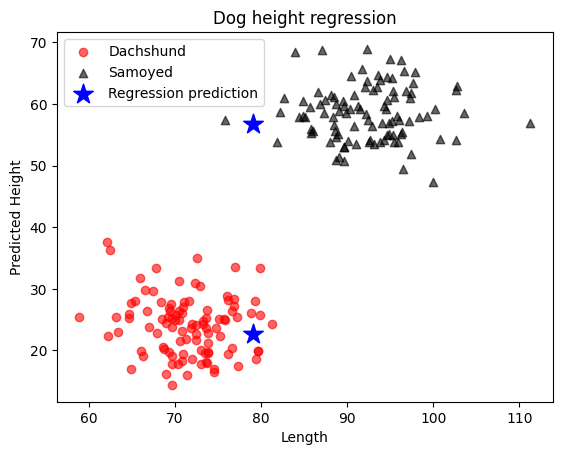

In [102]:
plt.scatter(new_dach_length, new_dach_height, c='red', alpha=0.6, label='Dachshund')
plt.scatter(new_samo_length, new_samo_height, c='black', marker='^', alpha=0.6, label='Samoyed')
plt.scatter(new_reg_dogs[:, 0], new_reg_dog_pred, c='blue', marker='*', s=220, label='Regression prediction')

plt.xlabel('Length')
plt.ylabel('Predicted Height')
plt.title('Dog height regression')
plt.legend(loc='upper left')
plt.show()